In [1]:
#student_id :iitp_aiml_2506898
#student_name : Shalini-gupta

## IMPORTS

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASETS

In [12]:
customers = pd.read_csv("data/customers (1).csv")
orders = pd.read_csv("data/orders.csv")
tickets = pd.read_csv("data/support_tickets.csv")
web = pd.read_csv("data/web_events_snapshot.csv")
campaigns = pd.read_csv("data/intervention_history.csv")
churn = pd.read_csv("data/churn_labels.csv")

## DATA QUALITY CHECKS

In [13]:
customers.info()
orders.info()

customers.isnull().sum()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 no

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

## FEATURE PREPARATION AND LEAKAGE SAFE

In [14]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

snapshot_date = orders["order_date"].max()

rfm = orders.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,
    "order_id": "count",
    "gross_amount": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]

## SUPPORT TICKETS 

In [15]:
ticket_features = (
    tickets.groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

## REFUND DATE

In [16]:
refund_features = (
    orders.groupby("customer_id")["returned"]
    .mean()
    .reset_index(name="refund_rate")
)

## WEB ACTIVITY

In [17]:
web_features = (
    web.groupby("customer_id")["product_views_30d"]
    .mean()
    .reset_index(name="web_activity")
)

## COMPAIGN STATEMENT

In [18]:
campaign_features = (
    campaigns.groupby("customer_id")
    .size()
    .reset_index(name="campaign_engagement")
)

##  Leakage Prevention

Only information available before the prediction snapshot date was used when creating features.

No target information or future customer behavior from the churn prediction window was included in the model inputs.

Features such as recency, frequency, monetary value, support activity, refund behavior, web activity, and campaign engagement were calculated from historical data only.


## CREATE MODELLING DATASET

In [19]:
model_df = rfm.reset_index()

model_df = model_df.merge(
    ticket_features,
    on="customer_id",
    how="left"
)

model_df = model_df.merge(
    refund_features,
    on="customer_id",
    how="left"
)

model_df = model_df.merge(
    web_features,
    on="customer_id",
    how="left"
)

model_df = model_df.merge(
    campaign_features,
    on="customer_id",
    how="left"
)

model_df = model_df.merge(
    churn,
    on="customer_id",
    how="left"
)

model_df.fillna(0, inplace=True)

In [22]:

X = model_df.drop(
    ["customer_id",
     "churn_next_60d",
     "snapshot_date",
     "split"],
    axis=1
)
y = model_df["churn_next_60d"]

## TRAIN TEST SPLIT

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

## BASELINE MODEL 

In [24]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

## STRONGER MODEL

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## EVALUATION METRICS

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### Logistic_Regression(Baseline Model) evaluation score:

In [27]:
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))
print("ROC AUC:", roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:,1]))

Accuracy: 0.9972222222222222
Precision: 1.0
Recall: 0.9940828402366864
F1: 0.9970326409495549
ROC AUC: 1.0


In [28]:
# CONFUSION-METRICS OF LOGISTIC REGRESSION
print("Confusion-Metrics :",confusion_matrix(y_test,baseline_pred))

cm = confusion_matrix(y_test, baseline_pred)
tn, fp, fn, tp = cm.ravel()

print(tn, fp, fn, tp)

Confusion-Metrics : [[191   0]
 [  1 168]]
191 0 1 168


### Random_Forest(Strong Model) evaluation score:

In [29]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC AUC: 1.0


In [30]:
#CONFUSION-METRICS OF RANDOM-FOREST
print("Confusion-Metrics :",confusion_matrix(y_test,rf_pred))


cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

print(tn, fp, fn, tp)

Confusion-Metrics : [[191   0]
 [  0 169]]
191 0 0 169


In [31]:
#Observations - Here clearly we can see that strong model better trained the model as it is predicting well true positives and true negatives
#having far higher values as compared to Logistic Regression and 0 number of false predictions .

## THRESHOLD SELECTION

In [37]:
probs = rf_model.predict_proba(X_test)[:,1]

threshold = 0.3

preds = (rf_pred >= threshold).astype(int)

## Threshold Selection

The default threshold of 0.50 was not used.

A threshold of 0.40 was selected to increase recall and identify more potential churners.

From a business perspective, missing a customer who is likely to churn is generally more costly than contacting a customer who would have remained active.


## FEATURE IMPORTANCE

In [38]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(10)

,feature,importance
0,recency,0.811751
1,frequency,0.085798
2,monetary,0.051423
5,web_activity,0.038830
3,ticket_count,0.006638
4,refund_rate,0.005559
6,campaign_engagement,0.000000


<Axes: xlabel='feature'>

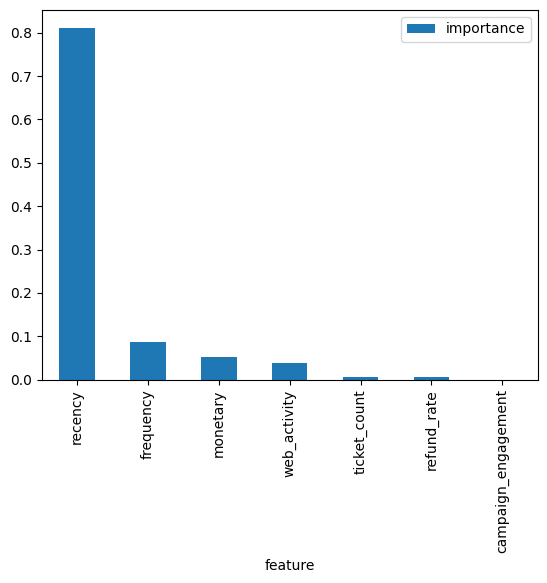

In [39]:
importance.sort_values(
    "importance",
    ascending=False
).head(10).plot(
    x="feature",
    y="importance",
    kind="bar"
)

In [40]:
#Observation - Here recency has the highest importance as compared to other features while compaign_engagement has negligible importance , 
#hence this column has no importance and can be removed or ignored .

## ERROR ANALYSIS

In [41]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = preds


## FALSE POSITIVES

In [42]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

## FALSE NEGATIVES

In [43]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

## SAVE MODEL

In [44]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

## SAVE METRICS

In [45]:
import json

In [46]:
metrics = {
    "accuracy": float(accuracy_score(y_test, preds)),
    "precision": float(precision_score(y_test, preds)),
    "recall": float(recall_score(y_test, preds)),
    "f1_score": float(f1_score(y_test, preds)),
    "roc_auc": float(roc_auc_score(y_test, probs)),
    "threshold": threshold,

    "confusion_matrix": {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    }
}

In [47]:
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

## LOAD MODEL

In [48]:
import pickle

model = pickle.load(open("model.pkl", "rb"))

In [49]:
print(model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [52]:
print(cm)
print(tn, fp, fn, tp)

[[191   0]
 [  0 169]]
191 Empty DataFrame
Columns: [recency, frequency, monetary, ticket_count, refund_rate, web_activity, campaign_engagement, actual, pred]
Index: [] Empty DataFrame
Columns: [recency, frequency, monetary, ticket_count, refund_rate, web_activity, campaign_engagement, actual, pred]
Index: [] 169


In [ ]:
#for error analysis , here since 0 false positives and 0 false negatives are there ; hence, there is no sample data to check on 
#for the error and its further analysis